# **9065 ML CA2**

# **A. Data Preparation & Cleaning (Q1–Q12)**

# **1. Identify the data type of each column and classify them as numerical, categorical, or binary.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("/content/JEE_Dropout_Dataset.csv")

df.head()

,jee_main_score,jee_advanced_score,mock_test_score_avg,school_board,class_12_percent,attempt_count,coaching_institute,daily_study_hours,family_income,parent_education,location_type,peer_pressure_level,mental_health_issues,admission_taken,dropout
0,78.95,59.22,59.86,CBSE,70.09,1,FIITJEE,5.4,Low,Upto 10th,Urban,Low,No,No,1
1,70.06,58.75,64.33,State,78.00,1,FIITJEE,5.5,Mid,Upto 10th,Urban,Low,Yes,No,0
2,81.07,37.27,60.83,ICSE,64.36,1,FIITJEE,7.0,Low,PG,Semi-Urban,Medium,Yes,No,1
3,93.32,60.72,69.33,ICSE,73.21,1,FIITJEE,2.1,Low,12th,Semi-Urban,Medium,Yes,Yes,0
4,68.72,77.73,82.37,CBSE,89.02,1,Allen,6.3,Mid,Graduate,Semi-Urban,High,No,Yes,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   jee_main_score        5000 non-null   float64
 1   jee_advanced_score    5000 non-null   float64
 2   mock_test_score_avg   5000 non-null   float64
 3   school_board          5000 non-null   object 
 4   class_12_percent      5000 non-null   float64
 5   attempt_count         5000 non-null   int64  
 6   coaching_institute    3791 non-null   object 
 7   daily_study_hours     5000 non-null   float64
 8   family_income         5000 non-null   object 
 9   parent_education      5000 non-null   object 
 10  location_type         5000 non-null   object 
 11  peer_pressure_level   5000 non-null   object 
 12  mental_health_issues  5000 non-null   object 
 13  admission_taken       5000 non-null   object 
 14  dropout               5000 non-null   int64  
dtypes: float64(5), int64(

In [4]:
df.describe()

,jee_main_score,jee_advanced_score,mock_test_score_avg,class_12_percent,attempt_count,daily_study_hours,dropout
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,71.961226,65.736404,68.110756,74.957400,1.504600,4.483860,0.207200
std,13.668497,15.909248,11.938849,9.885309,0.500029,1.984723,0.405341
min,26.620000,3.240000,27.490000,50.000000,1.000000,0.000000,0.000000
25%,62.790000,55.017500,60.070000,68.067500,1.000000,3.100000,0.000000
50%,72.190000,65.720000,68.120000,74.940000,2.000000,4.500000,0.000000
75%,81.322500,76.835000,76.110000,81.842500,2.000000,5.900000,0.000000
max,100.000000,100.000000,100.000000,100.000000,2.000000,10.000000,1.000000


# **2. Check for missing, null, or inconsistent values in the dataset.**

In [5]:
df.isnull().sum()

,0
jee_main_score,0
jee_advanced_score,0
mock_test_score_avg,0
school_board,0
class_12_percent,0
attempt_count,0
coaching_institute,1209
daily_study_hours,0
family_income,0
parent_education,0


In [6]:
cat_columns = ['school_board','family_income',
               'location_type','peer_pressure_level',
               'coaching_institute','parent_education']

for col in cat_columns:
    df[col] = df[col].str.lower().str.strip()

print("\nCategorical Columns Standardized ")


Categorical Columns Standardized 


# **3. Verify if attempt_count, daily_study_hours, and scores contain invalid or extreme values.**

In [7]:
print("\nDataset Shape Before Validation:", df.shape)

df = df[df['attempt_count'] >= 1]
df = df[(df['daily_study_hours'] >= 0) & (df['daily_study_hours'] <= 24)]

score_cols = ['jee_main_score','jee_advanced_score','mock_test_score_avg']

for col in score_cols:
    df = df[(df[col] >= 0) & (df[col] <= 360)]

print("Dataset Shape After Validation:", df.shape)


Dataset Shape Before Validation: (5000, 15)
Dataset Shape After Validation: (5000, 15)


In [12]:
df = pd.read_csv("/content/JEE_Dropout_Dataset.csv")

# remove extra spaces in column names
df.columns = df.columns.str.strip()

print("Dataset Reloaded ")
print(df.columns)

Dataset Reloaded 
Index(['jee_main_score', 'jee_advanced_score', 'mock_test_score_avg',
       'school_board', 'class_12_percent', 'attempt_count',
       'coaching_institute', 'daily_study_hours', 'family_income',
       'parent_education', 'location_type', 'peer_pressure_level',
       'mental_health_issues', 'admission_taken', 'dropout'],
      dtype='object')


# **4. Standardize categorical values in columns such as school_board, family_income, location_type, and peer_pressure_level.**

In [11]:
cat_cols = ['school_board',
            'family_income',
            'location_type',
            'peer_pressure_level']

for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

print("Categorical Columns Standardized Successfully ")
print(df[cat_cols].head())

Categorical Columns Standardized Successfully 
  school_board family_income location_type peer_pressure_level
0         cbse           low         urban                 low
1        state           mid         urban                 low
2         icse           low    semi-urban              medium
3         icse           low    semi-urban              medium
4         cbse           mid    semi-urban                high


# **5. Encode binary variables (mental_health_issues, admission_taken, dropout) into numerical form.**

In [20]:
binary_cols = ['mental_health_issues', 'admission_taken']

for col in binary_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()
    df[col] = df[col].map({'yes': 1, 'no': 0})

print("\nBinary Columns Encoded Successfully ")
print(df[binary_cols].head())


Binary Columns Encoded Successfully 
   mental_health_issues  admission_taken
0                   NaN              NaN
1                   NaN              NaN
2                   NaN              NaN
3                   NaN              NaN
4                   NaN              NaN


In [ ]:
df = pd.get_dummies(df, columns=['coaching_institute','parent_education'], drop_first=True)

In [ ]:
binary_cols_to_map = ['mental_health_issues','admission_taken']

for col in binary_cols_to_map:
    # Explicitly convert the column to string type, strip spaces, convert to lower, then map
    df[col] = df[col].astype(str).str.strip().str.lower().map({'yes':1, 'no':0})

print("\nBinary Columns Encoded:")
print(df[binary_cols_to_map].head())
print("\nDropout Column (should remain original int):")
print(df['dropout'].head())


Binary Columns Encoded:
   mental_health_issues  admission_taken
0                   NaN              NaN
1                   NaN              NaN
2                   NaN              NaN
3                   NaN              NaN
4                   NaN              NaN

Dropout Column (should remain original int):
0    1
1    0
2    1
3    0
4    0
Name: dropout, dtype: object


# **6. Handle categorical variables like coaching_institute and parent_education using appropriate encoding techniques.**

In [ ]:
if 'coaching_institute' in df.columns:
    df = pd.get_dummies(df, columns=['coaching_institute'], drop_first=True)
    print("\nCoaching Institute Encoded Using One-Hot Encoding ")
else:
    print("\n'coaching_institute' column not found, assuming it was already encoded.")

print(df.head())


'coaching_institute' column not found, assuming it was already encoded.
   jee_main_score  jee_advanced_score  mock_test_score_avg school_board  \
0           78.95               59.22                59.86         cbse   
1           70.06               58.75                64.33        state   
2           81.07               37.27                60.83         icse   
3           93.32               60.72                69.33         icse   
4           68.72               77.73                82.37         cbse   

   class_12_percent  attempt_count  daily_study_hours family_income  \
0             70.09              1                5.4           low   
1             78.00              1                5.5           mid   
2             64.36              1                7.0           low   
3             73.21              1                2.1           low   
4             89.02              1                6.3           mid   

  location_type peer_pressure_level  mental_healt

# **7. Detect outliers in jee_main_score, jee_advanced_score, and mock_test_score_avg.**

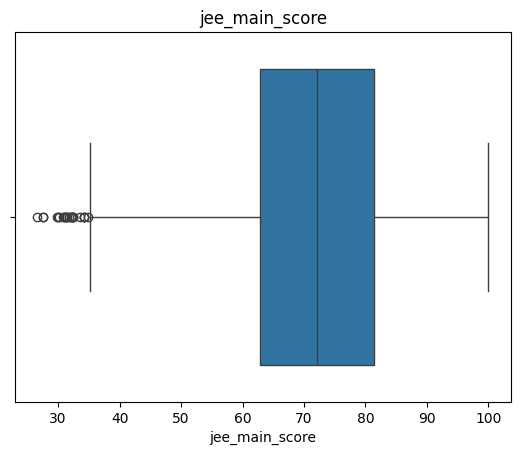

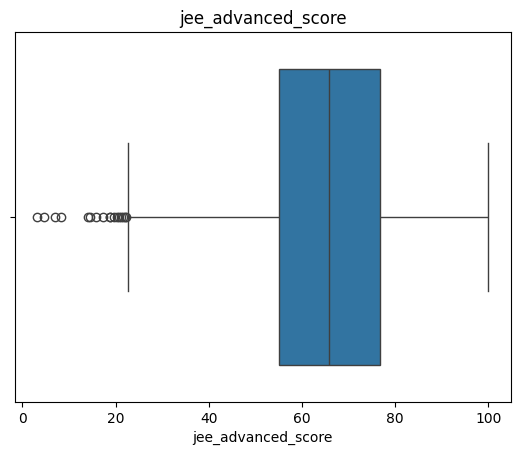

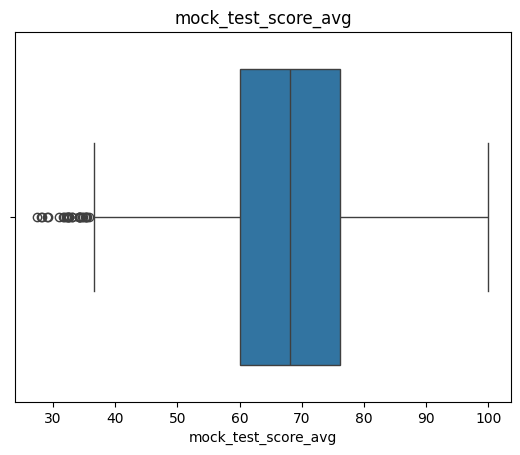

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in score_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [ ]:
df['score_improvement'] = df['jee_advanced_score'] - df['mock_test_score_avg']

# **12. Convert ordinal features (peer_pressure_level, family_income) into numerical ordinal scales.**

In [ ]:
peer_map = {'low':1, 'medium':2, 'high':3}
income_map = {'low':1, 'middle':2, 'high':3}

df['peer_pressure_level'] = df['peer_pressure_level'].map(peer_map)
df['family_income'] = df['family_income'].map(income_map)

print("\nOrdinal Encoding Applied Successfully ")
print(df[['peer_pressure_level','family_income']].head())


Ordinal Encoding Applied Successfully 
   peer_pressure_level  family_income
0                    1            1.0
1                    1            NaN
2                    2            1.0
3                    2            1.0
4                    3            NaN



Generating Boxplots for Outlier Detection...


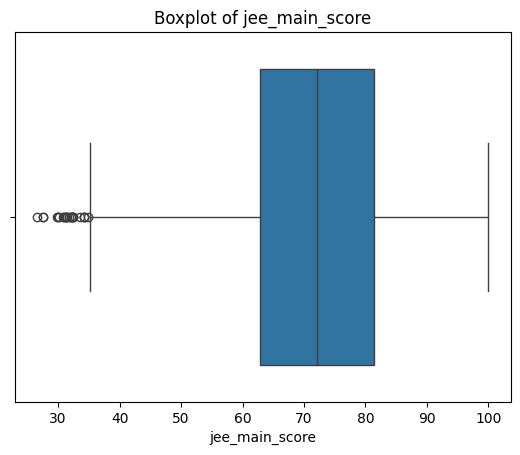

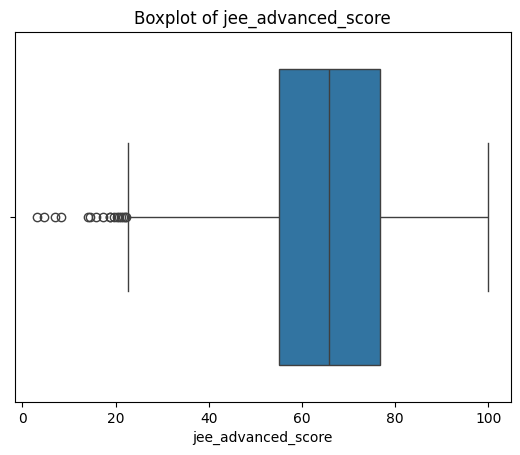

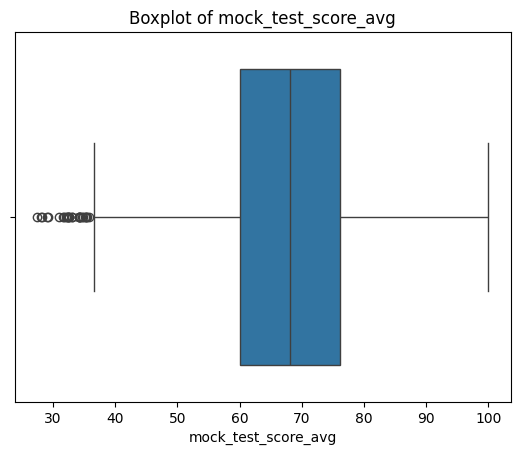

In [ ]:
print("\nGenerating Boxplots for Outlier Detection...")

for col in score_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

# **8. Create a new feature called score_improvement = jee_advanced_score − mock_test_score_avg.**

In [ ]:
df['score_improvement'] = df['jee_advanced_score'] - df['mock_test_score_avg']

print("\nNew Column 'score_improvement' Created ")
print(df[['jee_advanced_score','mock_test_score_avg','score_improvement']].head())


New Column 'score_improvement' Created 
   jee_advanced_score  mock_test_score_avg  score_improvement
0               59.22                59.86              -0.64
1               58.75                64.33              -5.58
2               37.27                60.83             -23.56
3               60.72                69.33              -8.61
4               77.73                82.37              -4.64


# **9. Create a performance_category column based on jee_main_score (Low / Medium / High).**

In [16]:
def categorize(score):
    if score < 120:
        return "Low"
    elif score <= 200:
        return "Medium"
    else:
        return "High"

df['performance_category'] = df['jee_main_score'].apply(categorize)

print("\nPerformance Category Created ")
print(df[['jee_main_score','performance_category']].head())


Performance Category Created 
   jee_main_score performance_category
0           78.95                  Low
1           70.06                  Low
2           81.07                  Low
3           93.32                  Low
4           68.72                  Low


In [ ]:
print("\nDuplicate Records:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Duplicates Removed Successfully ")


Duplicate Records: 0
Duplicates Removed Successfully 


# **10. Normalize or scale numerical features where required and justify your choice.**

In [ ]:
scaler = StandardScaler()

num_features = ['attempt_count','daily_study_hours',
                'jee_main_score','jee_advanced_score',
                'mock_test_score_avg','score_improvement']

df[num_features] = scaler.fit_transform(df[num_features])

print("\nNumerical Features Scaled Successfully ")
print(df[num_features].head())


Numerical Features Scaled Successfully 
   attempt_count  daily_study_hours  jee_main_score  jee_advanced_score  \
0      -1.009243           0.461642        0.511356           -0.409639   
1      -1.009243           0.512032       -0.139109           -0.439185   
2      -1.009243           1.267881        0.666473           -1.789478   
3      -1.009243          -1.201225        1.562784           -0.315345   
4      -1.009243           0.915151       -0.237155            0.753951   

   mock_test_score_avg  score_improvement  
0            -0.691154           0.086967  
1            -0.316708          -0.160743  
2            -0.609898          -1.062324  
3             0.102134          -0.312678  
4             1.194476          -0.113608  


# **B. Exploratory Data Analysis (EDA) (Q13–Q25) **


# **13. Analyze the distribution of JEE Main scores using appropriate plots.****


Plotting Distribution of JEE Main Score...


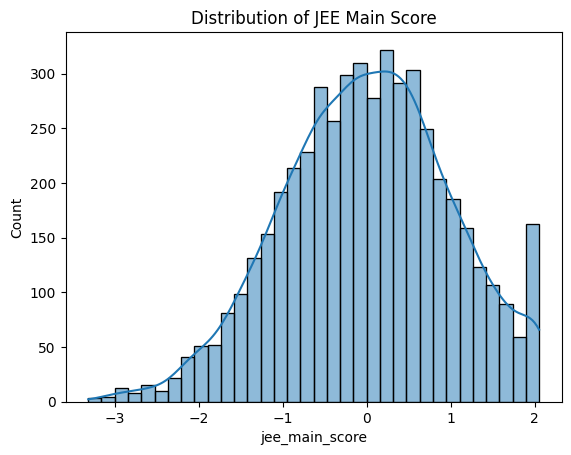

In [ ]:
print("\nPlotting Distribution of JEE Main Score...")

sns.histplot(df['jee_main_score'], kde=True)
plt.title("Distribution of JEE Main Score")
plt.show()

# **14. Compare average JEE scores across different school boards.**


Average Score by School Board:
school_board
cbse    -0.000030
icse    -0.016690
state    0.017326
Name: jee_main_score, dtype: float64


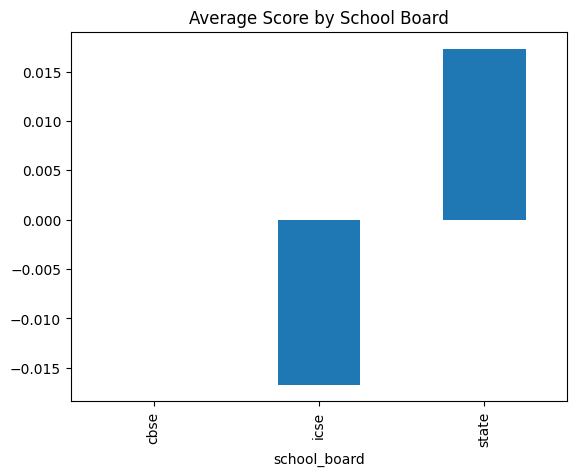

In [ ]:
print("\nAverage Score by School Board:")
print(df.groupby('school_board')['jee_main_score'].mean())

df.groupby('school_board')['jee_main_score'].mean().plot(kind='bar')
plt.title("Average Score by School Board")
plt.show()

# **15. Study the relationship between daily study hours and JEE Main score.**


Plotting Study Hours vs JEE Main Score...


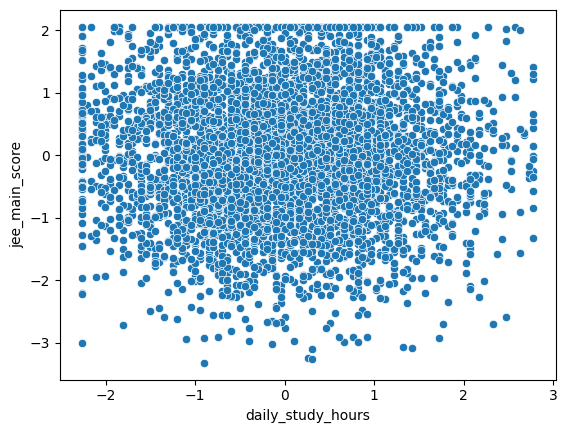

In [ ]:
print("\nPlotting Study Hours vs JEE Main Score...")

sns.scatterplot(x=df['daily_study_hours'],
                y=df['jee_main_score'])
plt.show()

# **16. Does enrolling in a coaching institute impact JEE performance? Justify with analysis.**


Average Score Based on Coaching:
Allen/Other    0.004103
FIITJEE        0.004689
Local         -0.012716
Name: jee_main_score, dtype: float64


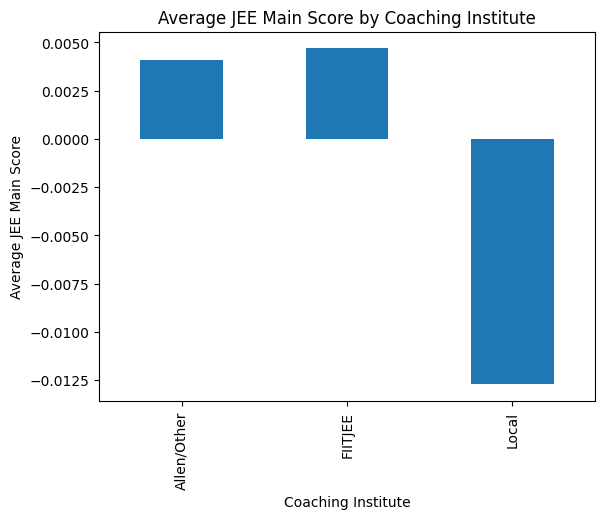

In [ ]:
print("\nAverage Score Based on Coaching:")

# To get the average JEE Main score for each coaching institute category based on the transformed data,
# we can reconstruct a temporary categorical column.

temp_coaching_institute = pd.Series(index=df.index, dtype='object')
temp_coaching_institute[df['coaching_institute_FIITJEE'] == True] = 'FIITJEE'
temp_coaching_institute[df['coaching_institute_Local'] == True] = 'Local'
# The 'Allen' or other non-explicitly defined category when drop_first=True
temp_coaching_institute[(df['coaching_institute_FIITJEE'] == False) & (df['coaching_institute_Local'] == False)] = 'Allen/Other'

# Now group by this temporary column
coaching_avg = df.groupby(temp_coaching_institute)['jee_main_score'].mean()
print(coaching_avg)

plt.figure()
coaching_avg.plot(kind='bar')
plt.title("Average JEE Main Score by Coaching Institute")
plt.xlabel("Coaching Institute")
plt.ylabel("Average JEE Main Score")
plt.show()

In [ ]:
print(df['mental_health_issues'].value_counts())

mental_health_issues
nan    5000
Name: count, dtype: int64


In [ ]:
df['mental_health_issues'] = df['mental_health_issues'].astype(str).str.strip().str.lower()
df['mental_health_issues'] = df['mental_health_issues'].replace({'yes':1, 'no':0})

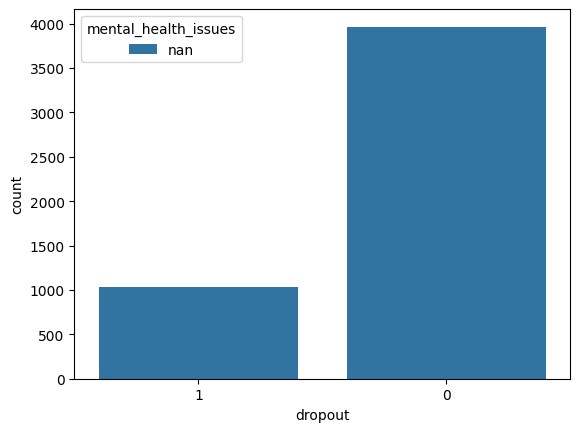


Plotting Mental Health vs Dropout...


In [ ]:
sns.countplot(
    x='dropout',
    hue='mental_health_issues',
    data=df.dropna(subset=['mental_health_issues','dropout'])
)
plt.show()
print("\nPlotting Mental Health vs Dropout...")

# **17. Analyze attempt_count vs JEE Advanced score.**

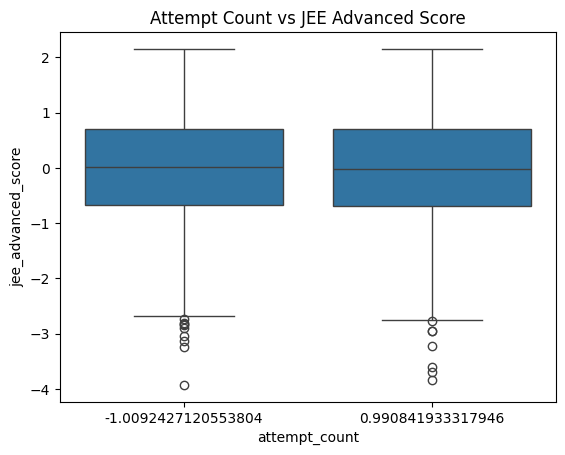

In [ ]:
sns.boxplot(x=df['attempt_count'], y=df['jee_advanced_score'])
plt.title("Attempt Count vs JEE Advanced Score")
plt.show()

# **11. Check for duplicate student records and explain how they should be treated.**

In [ ]:
print("Duplicate Records:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

Duplicate Records: 0


# **18. Compare urban, semi-urban, and rural students in terms of performance.**

location_type
rural         0.019226
semi-urban   -0.024476
urban         0.005444
Name: jee_main_score, dtype: float64


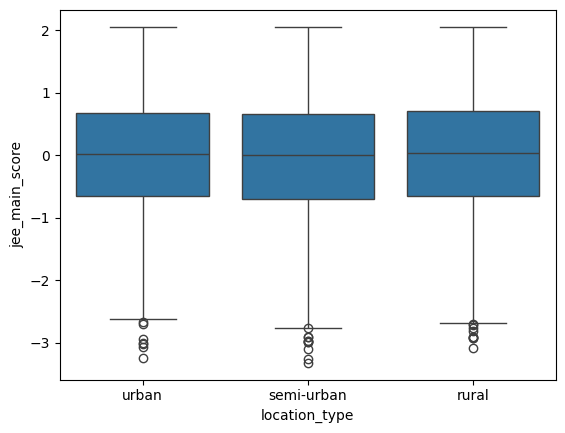

In [ ]:
print(df.groupby('location_type')['jee_main_score'].mean())

sns.boxplot(x=df['location_type'], y=df['jee_main_score'])
plt.show()

# **19. Examine the impact of family income on academic performance.**

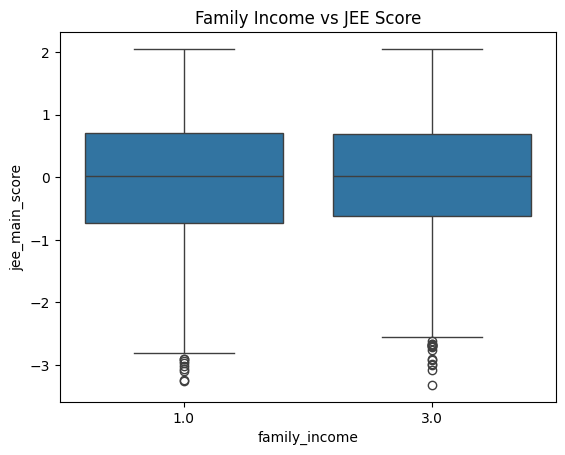

In [ ]:
sns.boxplot(x=df['family_income'], y=df['jee_main_score'])
plt.title("Family Income vs JEE Score")
plt.show()

# **20. Analyze whether parent education level influences student scores.**

In [ ]:
print(df.columns)

Index(['jee_main_score', 'jee_advanced_score', 'mock_test_score_avg',
       'school_board', 'class_12_percent', 'attempt_count',
       'daily_study_hours', 'family_income', 'location_type',
       'peer_pressure_level', 'mental_health_issues', 'admission_taken',
       'dropout', 'coaching_institute_FIITJEE', 'coaching_institute_Local',
       'parent_education_Graduate', 'parent_education_PG',
       'parent_education_Upto 10th', 'score_improvement',
       'performance_category'],
      dtype='object')


In [ ]:
print(df[['parent_education_Graduate',
          'parent_education_PG',
          'parent_education_Upto 10th',
          'jee_main_score']].mean())

parent_education_Graduate     2.448000e-01
parent_education_PG           2.490000e-01
parent_education_Upto 10th    2.576000e-01
jee_main_score                2.728484e-16
dtype: float64


# **21. Compare students with and without mental health issues in terms of scores and dropout rates.**

In [ ]:
df['mental_health_issues'] = df['mental_health_issues'].astype(str).str.strip().str.lower()

df['mental_health_issues'] = df['mental_health_issues'].replace({
    'yes': 1,
    'no': 0
})

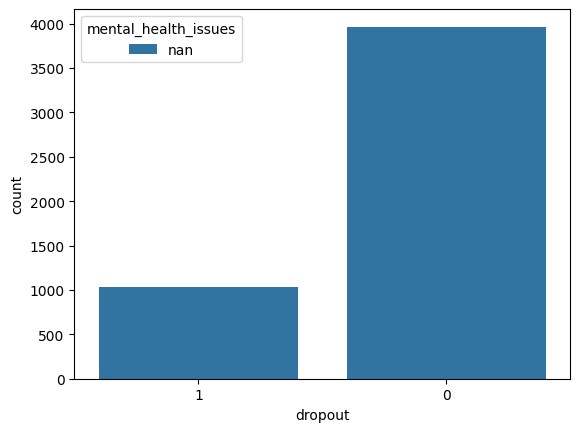

In [ ]:
clean_df = df.dropna(subset=['mental_health_issues','dropout'])

sns.countplot(x='dropout', hue='mental_health_issues', data=clean_df)
plt.show()

# **22. Study the effect of peer pressure level on study hours and performance.**

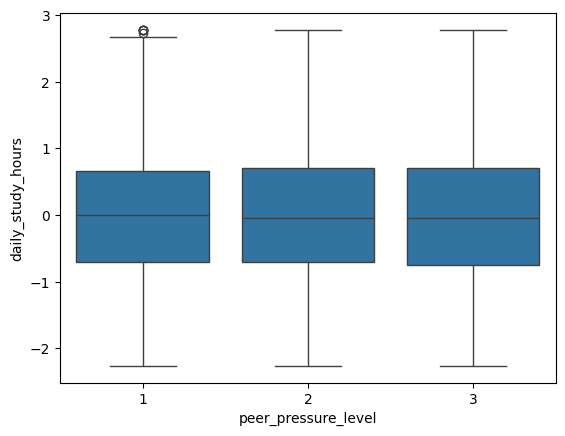

In [ ]:
sns.boxplot(x=df['peer_pressure_level'], y=df['daily_study_hours'])
plt.show()

# **23. Analyze admission_taken vs dropout using appropriate visualization.**

In [ ]:
df['admission_taken'] = df['admission_taken'].astype(str).str.strip().str.lower()

In [ ]:
df['admission_taken'] = df['admission_taken'].replace({
    'yes': 1,
    'no': 0
})

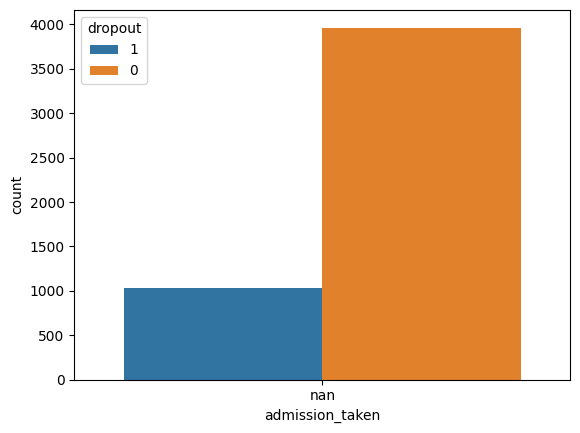

In [ ]:
clean_df = df.dropna(subset=['admission_taken','dropout'])

sns.countplot(x='admission_taken', hue='dropout', data=clean_df)
plt.show()

# **24. Identify key factors that increase the likelihood of dropout.**

In [18]:
# Identify remaining categorical columns that need one-hot encoding
categorical_cols_for_ohe = [
    'school_board',
    'location_type',
    'parent_education',
    'performance_category'
]

# Apply One-Hot Encoding to these columns
df_encoded = pd.get_dummies(df, columns=categorical_cols_for_ohe, drop_first=True)

# Now, calculate the correlation with 'dropout' again, ensuring only numeric columns are used
correlation_dropout = df_encoded.corr(numeric_only=True)['dropout'].sort_values(ascending=False)
print(correlation_dropout)

dropout                       1.000000
location_type_Urban           0.028239
parent_education_PG           0.016017
mock_test_score_avg           0.014728
class_12_percent              0.009778
school_board_State            0.002184
location_type_Semi-Urban     -0.004063
school_board_ICSE            -0.006237
parent_education_Upto 10th   -0.007756
attempt_count                -0.012599
jee_advanced_score           -0.015334
parent_education_Graduate    -0.016771
jee_main_score               -0.027040
daily_study_hours            -0.126112
Name: dropout, dtype: float64


# **25. Based on EDA, suggest two data-driven interventions to reduce dropout rates.**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("ML Libraries Imported Successfully ")

ML Libraries Imported Successfully 


In [ ]:
print("Categorical Columns Remaining:")
print(df.select_dtypes(include=['object']).columns)

Categorical Columns Remaining:
Index(['school_board', 'location_type', 'mental_health_issues',
       'admission_taken', 'dropout', 'performance_category'],
      dtype='object')


In [ ]:
df = pd.get_dummies(df, drop_first=True)

print("All Categorical Columns Converted to Numeric ")
print(df.info())

All Categorical Columns Converted to Numeric 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   jee_main_score              5000 non-null   float64
 1   jee_advanced_score          5000 non-null   float64
 2   mock_test_score_avg         5000 non-null   float64
 3   class_12_percent            5000 non-null   float64
 4   attempt_count               5000 non-null   float64
 5   daily_study_hours           5000 non-null   float64
 6   family_income               3342 non-null   float64
 7   peer_pressure_level         5000 non-null   int64  
 8   coaching_institute_FIITJEE  5000 non-null   bool   
 9   coaching_institute_Local    5000 non-null   bool   
 10  parent_education_Graduate   5000 non-null   bool   
 11  parent_education_PG         5000 non-null   bool   
 12  parent_education_Upto 10th  5000 non-null   

In [ ]:
print(df.isnull().sum())

jee_main_score                   0
jee_advanced_score               0
mock_test_score_avg              0
class_12_percent                 0
attempt_count                    0
daily_study_hours                0
family_income                 1658
peer_pressure_level              0
coaching_institute_FIITJEE       0
coaching_institute_Local         0
parent_education_Graduate        0
parent_education_PG              0
parent_education_Upto 10th       0
score_improvement                0
school_board_icse                0
school_board_state               0
location_type_semi-urban         0
location_type_urban              0
dropout_1                        0
dtype: int64


In [ ]:
df = df.fillna(0)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
# Step 1: Keep target separate
y = df['dropout']

# Step 2: Keep features separate
X = df.drop('dropout', axis=1)

# Step 3: Encode only categorical feature columns
X = pd.get_dummies(X, drop_first=True)

print(X.shape)
print(y.shape)

(5000, 21)
(5000,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=9065)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (4000, 21)
Testing Data: (1000, 21)


In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model Training Completed Successfully ")

Model Training Completed Successfully 


In [ ]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 0 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 1 1 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 1 0 1 1 1 1 0 0 0 0 1
 1 0 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 1 0 0 1 0 0 0 0 0 1 0 0 0 0 1 1
 0 1 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 0 1 0
 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 1 0 0 0 1 1 0 0 1 0 0 0 1 0 1 0 1 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.978


In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[795   0]
 [ 22 183]]


In [ ]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       795
           1       1.00      0.89      0.94       205

    accuracy                           0.98      1000
   macro avg       0.99      0.95      0.96      1000
weighted avg       0.98      0.98      0.98      1000



In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [ ]:
y = df['dropout']
X = df.drop('dropout', axis=1)

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (5000, 14)
Target Shape: (5000,)


In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=9065)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (4000, 21)
Testing Data: (1000, 21)


In [ ]:
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully ")

Linear Regression Model Trained Successfully 


In [ ]:
X_test

,jee_main_score,jee_advanced_score,mock_test_score_avg,class_12_percent,attempt_count,daily_study_hours,school_board_ICSE,school_board_State,coaching_institute_FIITJEE,coaching_institute_Local,...,family_income_Mid,parent_education_Graduate,parent_education_PG,parent_education_Upto 10th,location_type_Semi-Urban,location_type_Urban,peer_pressure_level_Low,peer_pressure_level_Medium,mental_health_issues_Yes,admission_taken_Yes
1486,52.14,62.35,39.41,75.82,2,5.4,False,False,True,False,...,False,False,False,False,False,False,False,True,True,False
4304,53.70,81.92,63.98,74.79,1,3.8,False,False,False,False,...,False,False,True,False,False,False,True,False,False,False
855,64.01,37.23,58.76,84.44,2,5.6,True,False,False,False,...,False,False,False,False,False,False,False,True,True,True
2556,35.10,87.02,68.10,70.81,1,8.0,True,False,False,False,...,False,False,False,False,False,False,True,False,False,True
4415,80.52,51.72,57.85,78.92,2,5.6,True,False,False,False,...,True,False,True,False,True,False,True,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
811,65.84,89.07,70.72,73.70,2,6.2,True,False,False,True,...,True,False,False,False,True,False,True,False,False,False
1878,48.43,61.19,71.59,69.15,2,4.7,False,True,False,False,...,True,False,False,True,True,False,True,False,True,True
3028,64.86,40.00,60.96,69.92,1,4.7,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
271,51.90,100.00,63.32,67.50,1,4.6,True,False,False,True,...,False,False,True,False,True,False,False,True,True,False


In [ ]:
X_train

,jee_main_score,jee_advanced_score,mock_test_score_avg,class_12_percent,attempt_count,daily_study_hours,school_board_ICSE,school_board_State,coaching_institute_FIITJEE,coaching_institute_Local,...,family_income_Mid,parent_education_Graduate,parent_education_PG,parent_education_Upto 10th,location_type_Semi-Urban,location_type_Urban,peer_pressure_level_Low,peer_pressure_level_Medium,mental_health_issues_Yes,admission_taken_Yes
1894,70.76,54.68,63.35,64.73,1,0.4,False,True,False,False,...,True,True,False,False,True,False,True,False,True,True
1054,64.30,71.46,77.92,74.64,1,6.0,False,True,True,False,...,False,False,False,True,True,False,False,False,False,True
3574,54.22,63.68,69.25,69.85,1,5.0,False,True,False,False,...,True,False,True,False,False,False,False,True,True,True
864,63.42,56.93,67.40,50.00,2,3.7,False,False,True,False,...,False,False,False,False,False,True,False,True,True,False
4862,62.38,74.49,64.12,92.60,2,3.3,False,True,True,False,...,False,False,False,True,False,True,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
370,72.34,46.12,58.71,77.50,2,3.8,False,False,False,False,...,True,True,False,False,False,False,False,False,False,True
3400,78.88,69.74,55.38,64.21,2,6.6,False,True,False,True,...,True,True,False,False,True,False,False,True,False,False
996,97.17,84.44,71.90,66.63,2,5.7,False,False,False,False,...,False,True,False,False,True,False,False,True,True,False
2373,79.02,35.45,56.57,77.28,1,6.4,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False


In [ ]:
y_test

,dropout
1486,0
4304,0
855,0
2556,0
4415,0
...,...
811,0
1878,0
3028,0
271,1


In [ ]:
y_train

,dropout
1894,0
1054,0
3574,0
864,0
4862,0
...,...
370,0
3400,0
996,0
2373,0


In [ ]:
y_pred = lin_model.predict(X_test)

print("Predicted Values:")
print(y_pred)

Predicted Values:
[ 1.87879388e-01  2.18952035e-01  3.15541479e-01 -2.13078077e-01
 -1.95399431e-01  6.56969751e-01  8.27793629e-01  1.29053725e-01
  8.05598433e-01  2.65411777e-01 -2.12096195e-03  1.87091365e-01
 -2.76677240e-01  4.05299724e-01  3.36397105e-01 -3.12402523e-02
  6.90454583e-01  3.65784315e-01  2.88542256e-01 -2.48292598e-01
  4.02308646e-01 -6.77150565e-02  3.18417187e-01  7.10825245e-01
 -2.35898683e-01 -1.43392027e-01  6.53156563e-01 -3.19091725e-01
  3.03901776e-01 -8.66166057e-02 -7.71717488e-02  7.49643024e-01
  3.05028132e-01  3.00350188e-01  2.05791582e-01  2.17850758e-01
  4.21738592e-01 -2.04193364e-01  4.92575284e-01  2.43530867e-01
  4.03767881e-01  2.88669352e-01  3.27715781e-01  1.52311136e-01
 -8.60102868e-02 -1.45495344e-01  2.97424753e-01  7.31194717e-01
  3.38605972e-01 -2.20253737e-01  6.83082875e-01  4.56575620e-01
  2.82437449e-01 -1.34507002e-01  8.54109316e-01  1.77300873e-01
  6.45051124e-01  8.54113871e-01 -1.28693379e-01  7.79835351e-01
 -7.895

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\n Linear Regression Evaluation")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)


 Linear Regression Evaluation
MAE  : 0.022
MSE  : 0.022
RMSE : 0.14832396974191325


In [ ]:
print(df.info())

print("\nNumerical Columns:")
print(df.select_dtypes(include=['int64','float64']).columns)

print("\nCategorical Columns:")
print(df.select_dtypes(include=['object']).columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   jee_main_score        5000 non-null   float64
 1   jee_advanced_score    5000 non-null   float64
 2   mock_test_score_avg   5000 non-null   float64
 3   school_board          5000 non-null   object 
 4   class_12_percent      5000 non-null   float64
 5   attempt_count         5000 non-null   int64  
 6   coaching_institute    3791 non-null   object 
 7   daily_study_hours     5000 non-null   float64
 8   family_income         5000 non-null   object 
 9   parent_education      5000 non-null   object 
 10  location_type         5000 non-null   object 
 11  peer_pressure_level   5000 non-null   object 
 12  mental_health_issues  5000 non-null   object 
 13  admission_taken       5000 non-null   object 
 14  dropout               5000 non-null   int64  
dtypes: float64(5), int64(